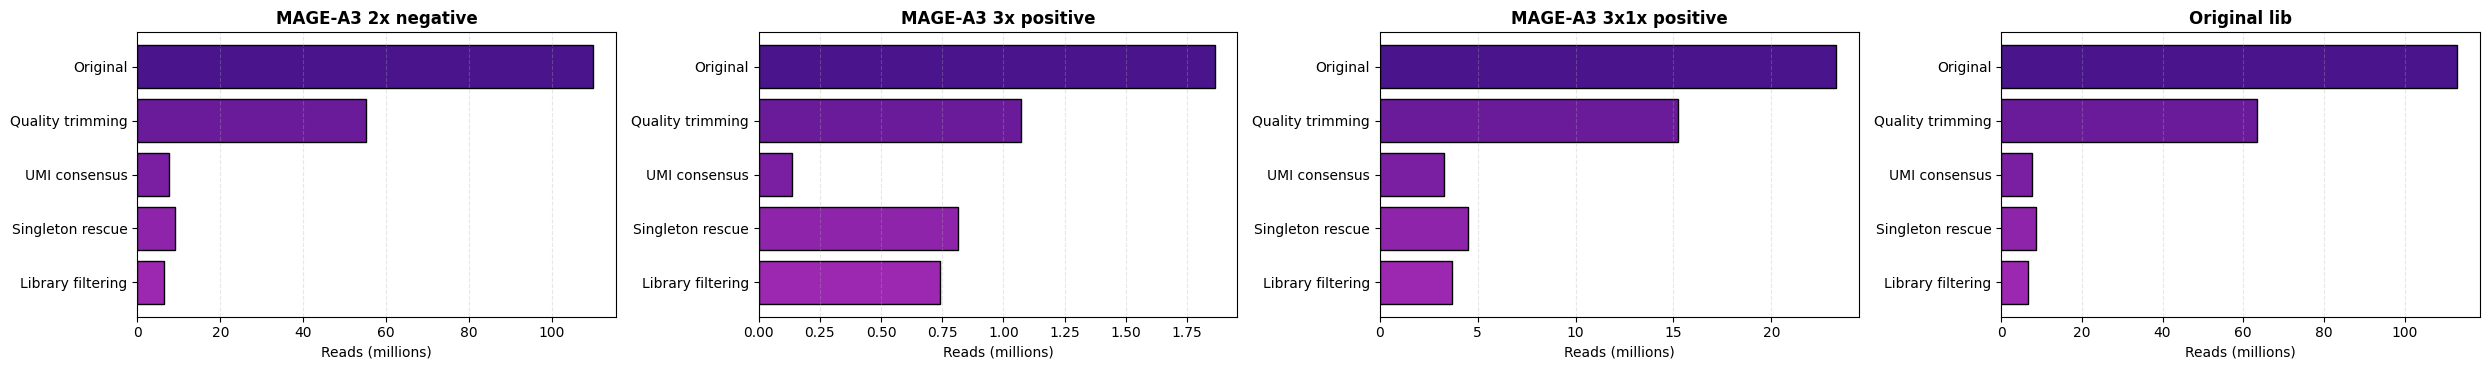

Saved: /cluster/project/reddy/katja/NGS_pipeline/visualization/presenation/A3_MAGEA3/pipeline_4subplots_bars.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Paths
base_path = Path('/cluster/project/reddy/katja/NGS_pipeline')
step1_path = base_path / 'visualization/presenation/A3_MAGEA3/step1_QC'
step2_path = base_path / 'visualization/presenation/A3_MAGEA3/step2_umi'
step2a_path = base_path / 'visualization/presenation/A3_MAGEA3/step2a_singleton'
step3_path = base_path / 'visualization/presenation/A3_MAGEA3/step3_filtering'

# Load data
bbduk_file = list(step1_path.glob('bbduk_summary*.csv'))[0]
bbduk_df = pd.read_csv(bbduk_file)

# UMI parsing helper

def parse_umi_file(filepath):
    text = Path(filepath).read_text()
    d = {}
    m = re.search(r'Total reads processed: (\d+)', text)
    if m: d['reads_processed'] = int(m.group(1))
    m = re.search(r'UMIs with >= 2 reads \(consensus\): (\d+)', text)
    if m: d['consensus_umis'] = int(m.group(1))
    m = re.search(r'Reads in singleton UMIs: (\d+)', text)
    if m: d['singleton_reads'] = int(m.group(1))
    return d

umi_files = {
    'GFB-61811': step2_path / 'GFB-61811_clibMAGE-A32xnegative_umi_summary.txt',
    'GFB-61822': step2_path / 'GFB-61822_clibMAGE-A33xpositive_umi_summary.txt',
    'GFB-61831': step2_path / 'GFB-61831_clibMAGE-A331xpositive_umi_summary.txt',
    'GFB-61840': step2_path / 'GFB-61840_cliboriginallib_umi_summary.txt'
}
umi_data = {s: parse_umi_file(p) for s, p in umi_files.items()}

singleton_df = pd.read_csv(step2a_path / 'singleton_rescue_summary.tsv', sep='\t')
filtering_df = pd.read_csv(step3_path / 'all_samples.filtered.summary.report.csv')

# Samples & labels
samples = [
    ('GFB-61811', 'MAGE-A3 2x negative'),
    ('GFB-61822', 'MAGE-A3 3x positive'),
    ('GFB-61831', 'MAGE-A3 3x1x positive'),
    ('GFB-61840', 'Original lib')
]

rows = []
mapping = {
    'GFB-61811': 'GFB-61811_clibMAGE-A32xnegative',
    'GFB-61822': 'GFB-61822_clibMAGE-A33xpositive',
    'GFB-61831': 'GFB-61831_clibMAGE-A331xpositive',
    'GFB-61840': 'GFB-61840_cliboriginallib'
}

for sid, label in samples:
    qc_rows = bbduk_df[bbduk_df['sample_id'] == sid]
    reads_in = int(qc_rows['reads_in'].sum())
    reads_qc = int(qc_rows['reads_out'].sum())
    consensus_umis = umi_data[sid].get('consensus_umis', 0)
    kept_reads = int(singleton_df[singleton_df['sample_id'] == sid]['kept_reads'].iloc[0])
    singleton_rescue_total = consensus_umis + kept_reads
    filter_row = filtering_df[filtering_df['sample'] == mapping[sid]].iloc[0]
    final_pass = int(filter_row['pass'])

    rows.append({
        'sample_id': sid,
        'label': label,
        'reads_in': reads_in,
        'reads_qc': reads_qc,
        'consensus_umis': consensus_umis,
        'singleton_rescue_total': singleton_rescue_total,
        'final_pass': final_pass
    })

plot_df = pd.DataFrame(rows).set_index('label')

# Colors (blue/violetish)
colors = ['#4A148C', '#6A1B9A', '#7B1FA2', '#8E24AA', '#9C27B0']
step_names = ['Original', 'Quality trimming', 'UMI consensus', 'Singleton rescue', 'Library filtering']

# Prepare figure: 3 subplots (3 samples), each with 5 horizontal bars
fig, axes = plt.subplots(1, 4, figsize=(23, 4))
axes = axes.flatten()

for ax, (label, row) in zip(axes, plot_df.iterrows()):
    values = [row['reads_in'], row['reads_qc'], row['consensus_umis'], row['singleton_rescue_total'], row['final_pass']]
    values_m = [v / 1e6 for v in values]
    y_pos = np.arange(len(values_m))
    ax.barh(y_pos, values_m, color=colors[:len(values_m)], edgecolor='k')
    #for yi, val in zip(y_pos, values):
        #ax.text(values_m[yi] + max(values_m)*0.01, yi, f"{int(val):,}", va='center', fontsize=9)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(step_names)
    ax.invert_yaxis()
    ax.set_xlabel('Reads (millions)')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

legend_patches = [plt.matplotlib.patches.Patch(color=c, label=n) for c, n in zip(colors, step_names)]
#fig.legend(handles=legend_patches, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.98))
#fig.suptitle('MAGE-A3 — Reads at each pipeline step (one subplot per sample)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

out = '/cluster/project/reddy/katja/NGS_pipeline/visualization/presenation/A3_MAGEA3/pipeline_4subplots_bars.png'
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print('Saved:', out)
